# Backtest analysis — `results/dates.csv`

Visualizes portfolio, signals, agent outlooks, agreement, costs, and a few extras. Paths resolve from repo root or `scripts/`.

**Setup:** `pip install ".[notebooks]"` (adds `matplotlib` and `jupyter`) or `pip install matplotlib jupyter` in your venv.

In [8]:
import os
import warnings
from pathlib import Path

_mpl = Path.cwd() / ".mpl_cache"
_mpl.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_mpl.resolve()))

import matplotlib

try:
    __IPYTHON__  # noqa: B018
except NameError:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Backtest metrics (Sharpe, Sortino, Calmar, gross vs net) are implemented in
# ``tradingagents.backtest.metrics`` — same formulas as ``summary.json`` from ``scripts/backtest_mvp.py``.

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings(
    "ignore", message="FigureCanvasAgg is non-interactive.*", category=UserWarning
)

try:
    from IPython.display import display
except ImportError:

    def display(obj=None, **kwargs):
        if obj is not None:
            print(obj)


for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    try:
        plt.style.use(_style)
        break
    except OSError:
        continue
plt.rcParams.update({"figure.figsize": (10, 4), "axes.titlesize": 12})


def resolve_dates_csv() -> Path:
    cwd = Path.cwd().resolve()
    for base in (cwd, cwd.parent):
        p = base / "results" / "dates.csv"
        if p.is_file():
            return p
    raise FileNotFoundError(
        "results/dates.csv not found. Open the notebook from the repo root or from scripts/."
    )


CSV_PATH = resolve_dates_csv()
print(f"Using {CSV_PATH}")


Using /Users/recro/OSS/hindsight2020/results/dates.csv


In [9]:
NUM_COLS = [
    "equity",
    "close",
    "cash",
    "shares",
    "fees_day",
    "cumulative_fees",
    "total_return",
    "annualized_return",
    "sharpe_ratio",
    "max_drawdown",
    "total_transaction_costs",
    "cost_bps",
]

raw = pd.read_csv(CSV_PATH)
raw.columns = [c.strip() for c in raw.columns]
raw["date"] = pd.to_datetime(raw["date"], errors="coerce")

for c in NUM_COLS:
    if c in raw.columns:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")

if "processed" in raw.columns:
    raw["processed"] = (
        raw["processed"].astype(str).str.strip().str.upper().eq("TRUE")
    )

err = raw["error"].fillna("").astype(str).str.strip().str.lower()
raw["is_trading_day"] = err.ne("not trading day")

df_all = raw.sort_values("date").reset_index(drop=True)
dtd = df_all[df_all["is_trading_day"]].copy().reset_index(drop=True)

# Derived series
dtd["position_value"] = dtd["shares"].fillna(0) * dtd["close"]
dtd["cash_weight"] = np.where(
    dtd["equity"].notna() & (dtd["equity"] != 0),
    dtd["cash"] / dtd["equity"],
    np.nan,
)

first = dtd.iloc[0]
init_equity = float(first["equity"]) if pd.notna(first["equity"]) else 100_000.0
close0 = float(first["close"])
shares_bh = init_equity / close0
dtd["benchmark_equity"] = dtd["close"] * shares_bh

inv = dtd[dtd["shares"].fillna(0) > 0]
if len(inv):
    i0 = inv.iloc[0]
    e0 = float(i0["equity"]) if pd.notna(i0["equity"]) else init_equity
    c0 = float(i0["close"])
    sh2 = e0 / c0
    dtd["benchmark_from_first_fill"] = dtd["close"] * sh2
else:
    dtd["benchmark_from_first_fill"] = np.nan

# Equity drawdown (from running peak)
eq = dtd["equity"]
peak = eq.cummax()
dtd["drawdown"] = np.where(peak > 0, eq / peak - 1.0, np.nan)

# Daily strategy return from equity
dtd["strat_daily_ret"] = dtd["equity"].pct_change()

# Forward closes
dtd["fwd_1d"] = dtd["close"].shift(-1) / dtd["close"] - 1
dtd["fwd_5d"] = dtd["close"].shift(-5) / dtd["close"] - 1

# Share changes (turnover proxy)
sh = dtd["shares"].fillna(0)
dtd["shares_chg"] = sh.diff().abs()
dtd["trade_event"] = (dtd["shares_chg"] > 1e-9) | (
    dtd["final_signal"].astype(str).str.upper().isin(["BUY", "SELL"])
)

OUTLOOK_COLS = [
    "market_outlook",
    "sentiment_outlook",
    "news_outlook",
    "fundamentals_outlook",
]

def _norm_outlook(s: pd.Series) -> pd.Series:
    return (
        s.fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({"": np.nan, "nan": np.nan})
    )


for c in OUTLOOK_COLS:
    if c in dtd.columns:
        dtd[c] = _norm_outlook(dtd[c])

SCORE_MAP = {"bullish": 1.0, "bearish": -1.0, "mixed": 0.0, "neutral": 0.0}


def outlook_numeric(series: pd.Series) -> pd.Series:
    return series.map(SCORE_MAP)


if all(c in dtd.columns for c in OUTLOOK_COLS):
    scores = pd.concat(
        [outlook_numeric(dtd[c]) for c in OUTLOOK_COLS], axis=1, keys=OUTLOOK_COLS
    )
    dtd["facet_mean"] = scores.mean(axis=1, skipna=True)
    dtd["facet_n_unique"] = (
        dtd[OUTLOOK_COLS].apply(
            lambda r: len({x for x in r if pd.notna(x) and str(x).strip()}), axis=1
        )
    )
    dtd["facet_spread"] = scores.max(axis=1, skipna=True) - scores.min(
        axis=1, skipna=True
    )
    dtd["is_fallback_row"] = (
        dtd[OUTLOOK_COLS].eq("fallback").any(axis=1)
        if len(OUTLOOK_COLS)
        else False
    )
else:
    dtd["is_fallback_row"] = False

for c in ("trader_decision", "risk_decision", "investment_recommendation", "final_signal", "processed_signal"):
    if c in dtd.columns:
        dtd[c] = (
            dtd[c].fillna("")
            .astype(str)
            .str.strip()
            .str.upper()
            .replace({"": np.nan, "NAN": np.nan})
        )


def match_signal(row, col):
    if col not in row.index or pd.isna(row.get(col)) or pd.isna(row.get("final_signal")):
        return np.nan
    return str(row[col]).upper() == str(row["final_signal"]).upper()


if "trader_decision" in dtd.columns:
    dtd["trader_matches_final"] = dtd.apply(
        lambda r: match_signal(r, "trader_decision"), axis=1
    )
if "risk_decision" in dtd.columns:
    dtd["risk_matches_final"] = dtd.apply(
        lambda r: match_signal(r, "risk_decision"), axis=1
    )

display(dtd.head(3))
print(f"Trading rows: {len(dtd)} / all rows {len(df_all)}")


,date,processed,final_signal,equity,error,close,cash,shares,fees_day,cumulative_fees,...,fwd_1d,fwd_5d,shares_chg,trade_event,facet_mean,facet_n_unique,facet_spread,is_fallback_row,trader_matches_final,risk_matches_final
0,2024-05-06,True,BUY,100000.00000,NaN,1419.50,0.0,70.447341,0.0,0.0,...,-0.012681,-0.011835,NaN,True,0.250000,3,1.0,False,True,True
1,2024-05-07,True,BUY,98731.94787,NaN,1401.50,0.0,70.447341,0.0,0.0,...,0.012166,0.013271,0.0,True,0.333333,2,1.0,False,True,True
2,2024-05-08,True,HOLD,99933.07503,NaN,1418.55,0.0,70.447341,0.0,0.0,...,-0.017236,-0.001586,0.0,False,0.000000,1,0.0,False,True,True


Trading rows: 95 / all rows 131


## 1. Portfolio, drawdown, exposure

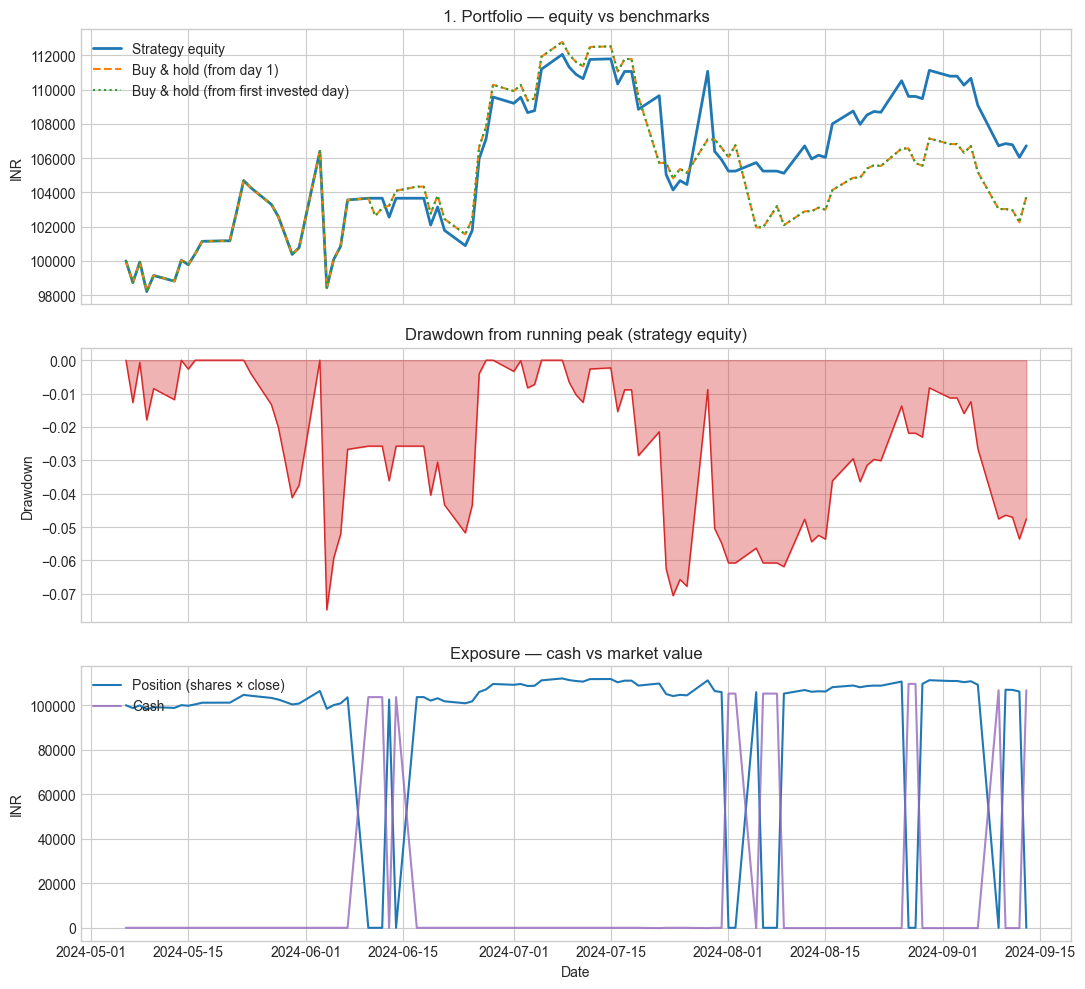

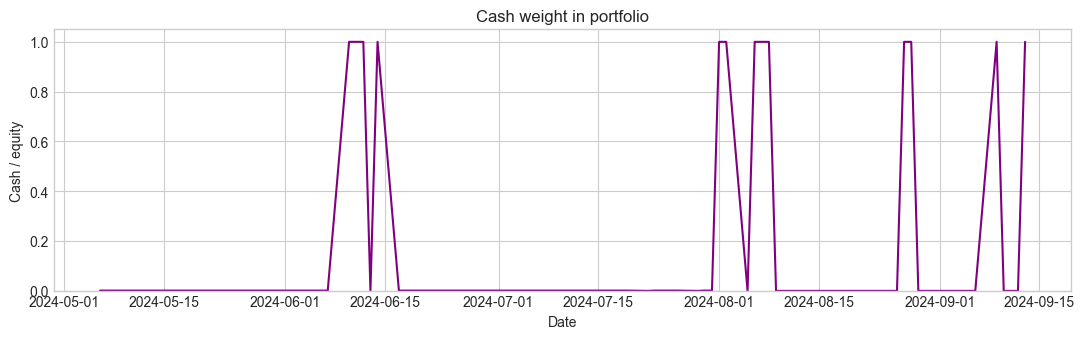

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

ax = axes[0]
ax.plot(dtd["date"], dtd["equity"], label="Strategy equity", color="C0", lw=2)
ax.plot(dtd["date"], dtd["benchmark_equity"], label="Buy & hold (from day 1)", color="C1", ls="--", lw=1.5)
if dtd["benchmark_from_first_fill"].notna().any():
    ax.plot(
        dtd["date"],
        dtd["benchmark_from_first_fill"],
        label="Buy & hold (from first invested day)",
        color="C2",
        ls=":",
        lw=1.5,
    )
ax.set_ylabel("INR")
ax.set_title("1. Portfolio — equity vs benchmarks")
ax.legend(loc="upper left")

ax = axes[1]
ax.fill_between(dtd["date"], dtd["drawdown"], 0, color="C3", alpha=0.35)
ax.plot(dtd["date"], dtd["drawdown"], color="C3", lw=1)
ax.set_ylabel("Drawdown")
ax.set_title("Drawdown from running peak (strategy equity)")

ax = axes[2]
ax.plot(dtd["date"], dtd["position_value"], label="Position (shares × close)", color="C0")
ax.plot(dtd["date"], dtd["cash"], label="Cash", color="C4", alpha=0.8)
ax.set_ylabel("INR")
ax.set_xlabel("Date")
ax.set_title("Exposure — cash vs market value")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(dtd["date"], dtd["cash_weight"], color="purple", lw=1.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Cash / equity")
ax.set_xlabel("Date")
ax.set_title("Cash weight in portfolio")
plt.tight_layout()
plt.show()


## 2. Signals, transitions, forward returns, activity

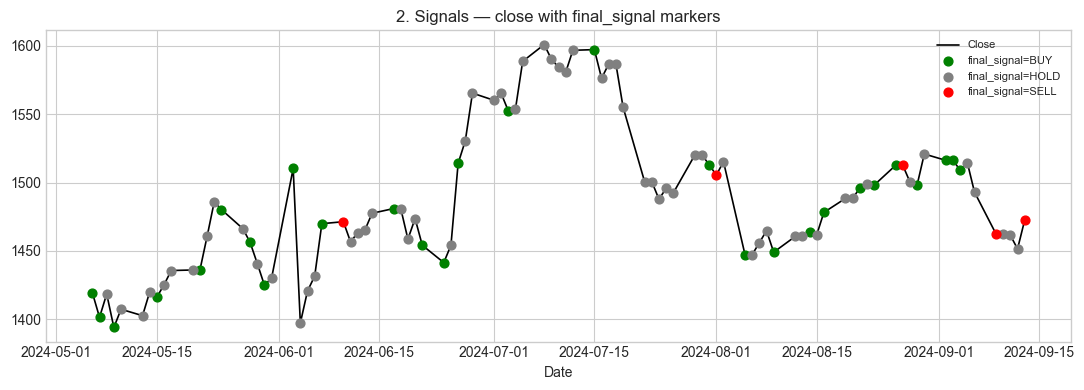

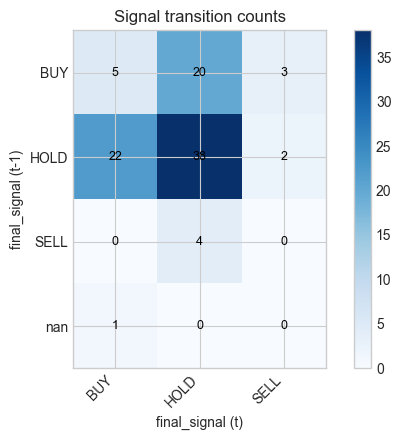

/var/folders/c3/wfchxxcj7l55l_b4xkk_6mpw0000gn/T/ipykernel_24767/1550217094.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
/var/folders/c3/wfchxxcj7l55l_b4xkk_6mpw0000gn/T/ipykernel_24767/1550217094.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)


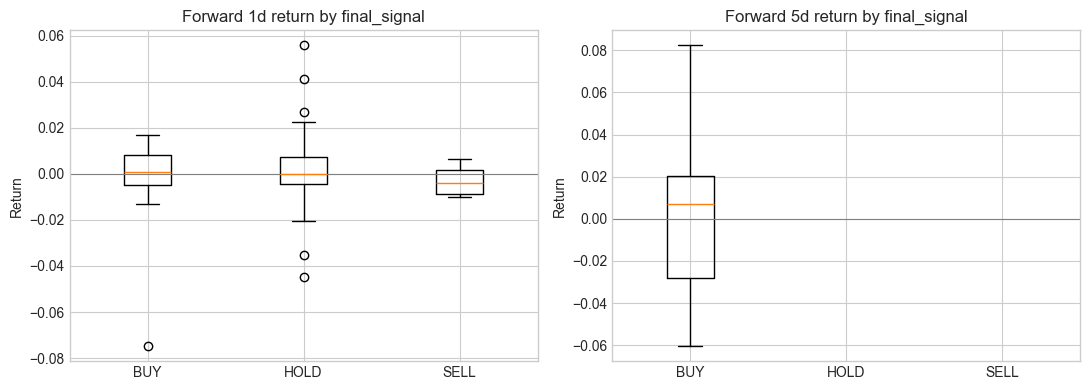

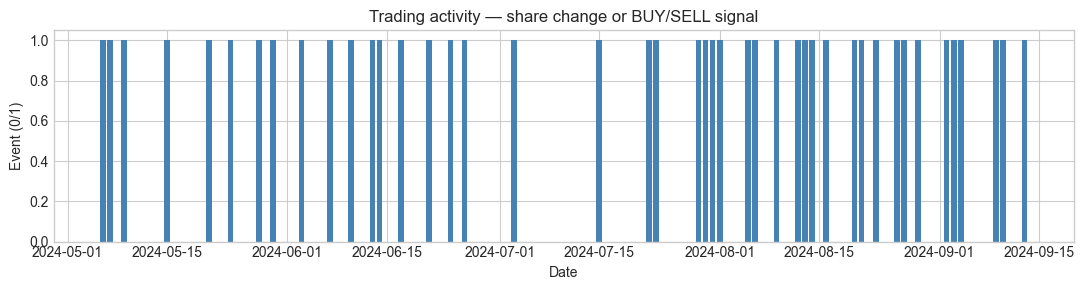

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(dtd["date"], dtd["close"], color="black", lw=1.2, label="Close")

sig = dtd["final_signal"].astype(str).str.upper()
colors = {"BUY": "green", "SELL": "red", "HOLD": "gray"}
for name, g in dtd.groupby(sig):
    c = colors.get(str(name).upper(), "blue")
    ax.scatter(g["date"], g["close"], c=c, s=40, zorder=3, label=f"final_signal={name}")

ax.set_title("2. Signals — close with final_signal markers")
ax.legend(loc="best", fontsize=8)
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

prev = sig.shift(1)
cur = sig
trans = pd.crosstab(prev, cur, dropna=False)
fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(trans.values, cmap="Blues")
ax.set_xticks(range(len(trans.columns)))
ax.set_xticklabels(trans.columns, rotation=45, ha="right")
ax.set_yticks(range(len(trans.index)))
ax.set_yticklabels(trans.index)
ax.set_xlabel("final_signal (t)")
ax.set_ylabel("final_signal (t-1)")
ax.set_title("Signal transition counts")
for i in range(trans.shape[0]):
    for j in range(trans.shape[1]):
        ax.text(j, i, int(trans.values[i, j]), ha="center", va="center", color="black", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

# Forward returns by signal (drop last rows without forward window)
sub = dtd.dropna(subset=["fwd_1d", "final_signal"])
if len(sub):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, col, title in zip(
        axes,
        ["fwd_1d", "fwd_5d"],
        ["Forward 1d return by final_signal", "Forward 5d return by final_signal"],
    ):
        data = [sub.loc[sub["final_signal"] == s, col].values for s in sorted(sub["final_signal"].dropna().unique())]
        labels = [str(s) for s in sorted(sub["final_signal"].dropna().unique())]
        ax.boxplot(data, labels=labels)
        ax.axhline(0, color="gray", lw=0.8)
        ax.set_title(title)
        ax.set_ylabel("Return")
    plt.tight_layout()
    plt.show()

# Activity
fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(dtd["date"], dtd["trade_event"].astype(int), width=0.8, color="steelblue")
ax.set_title("Trading activity — share change or BUY/SELL signal")
ax.set_ylabel("Event (0/1)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()


## 3. Agent facets and risk views

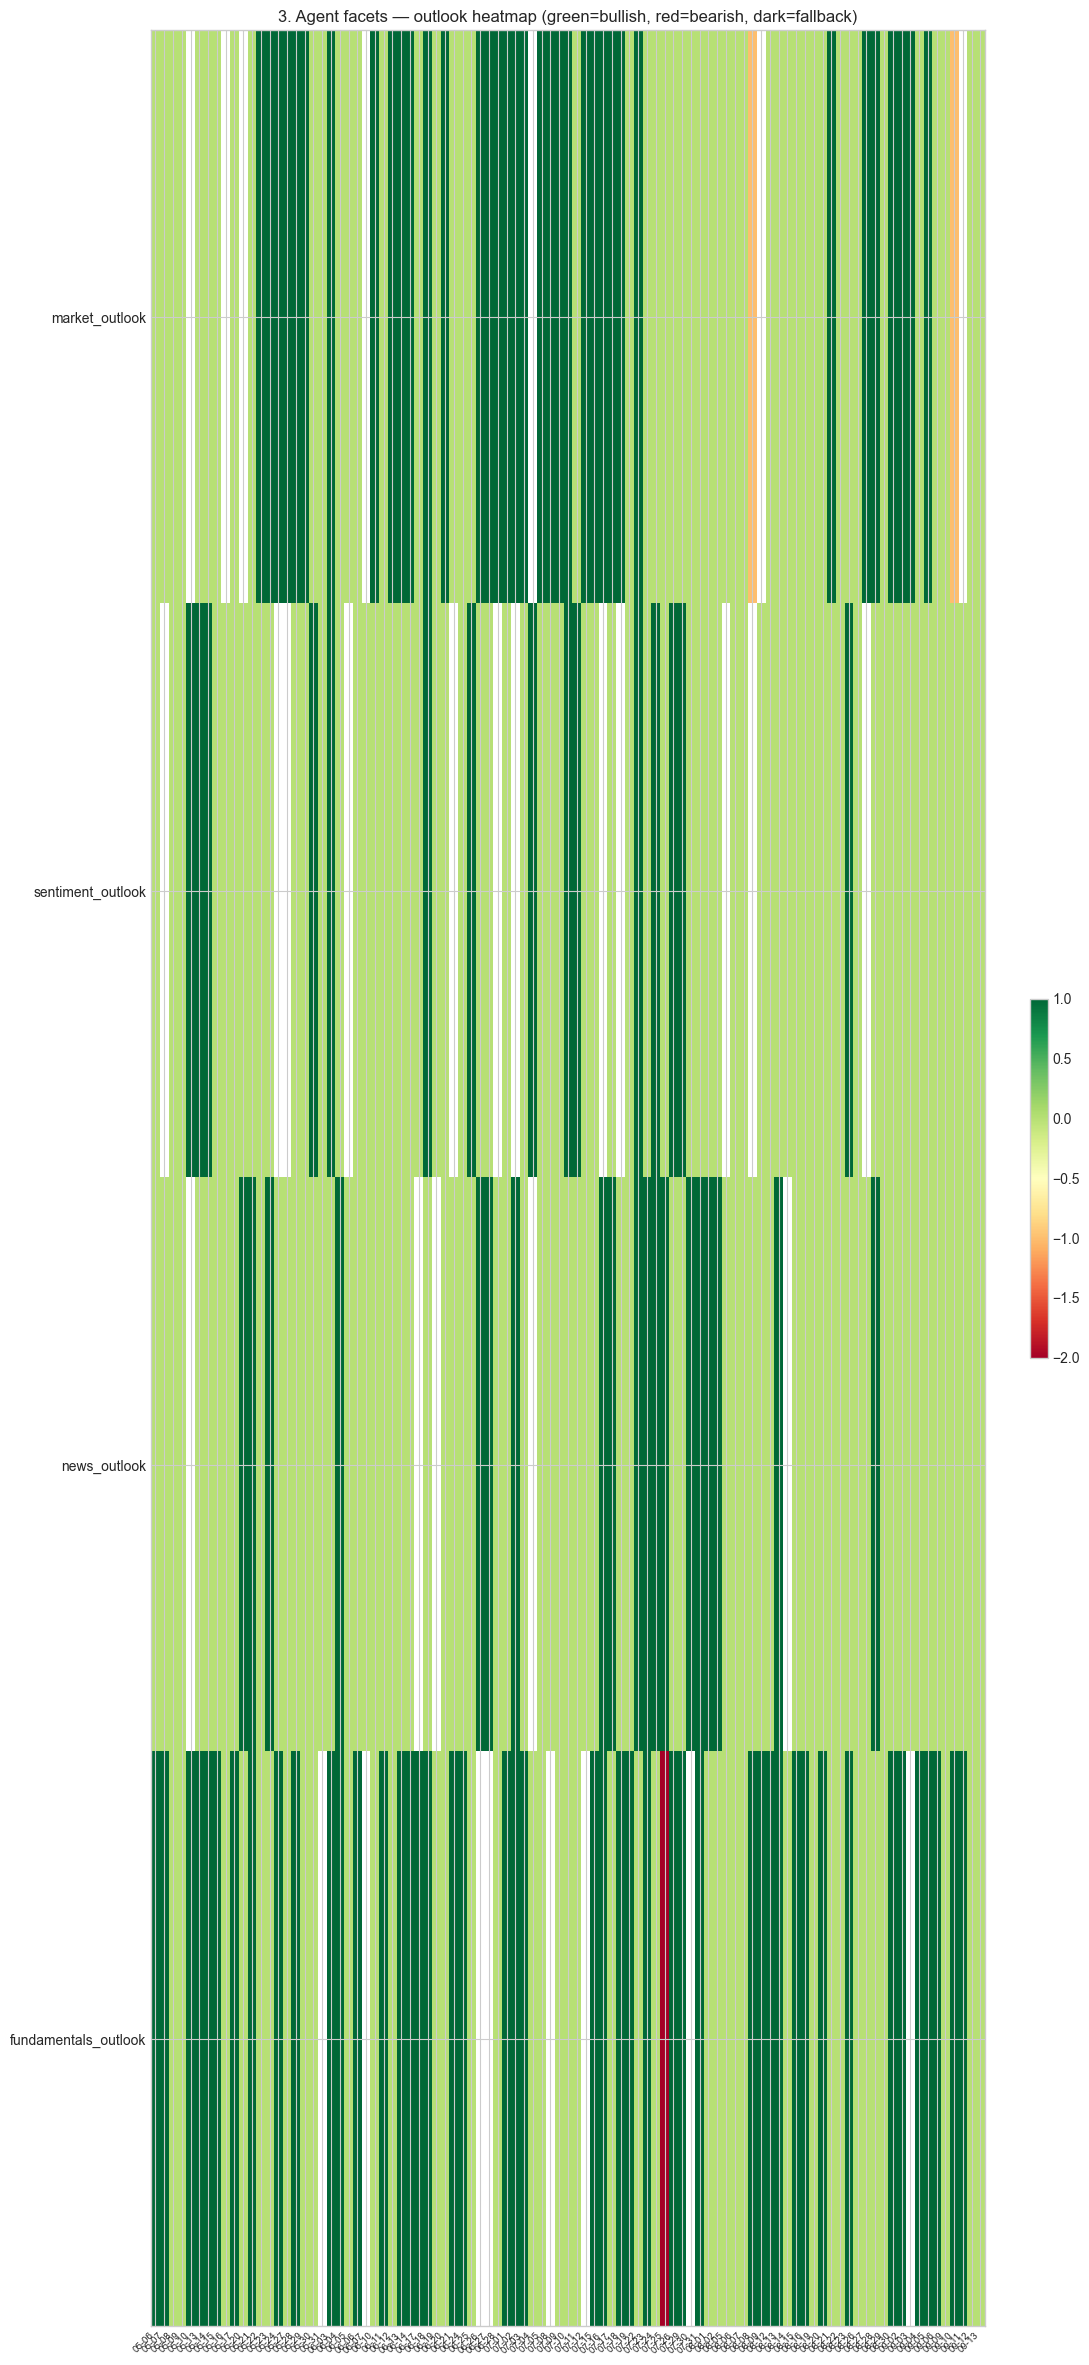

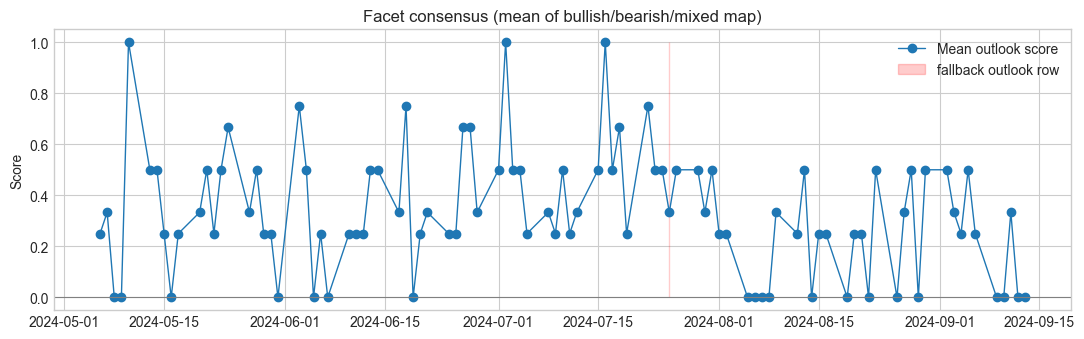

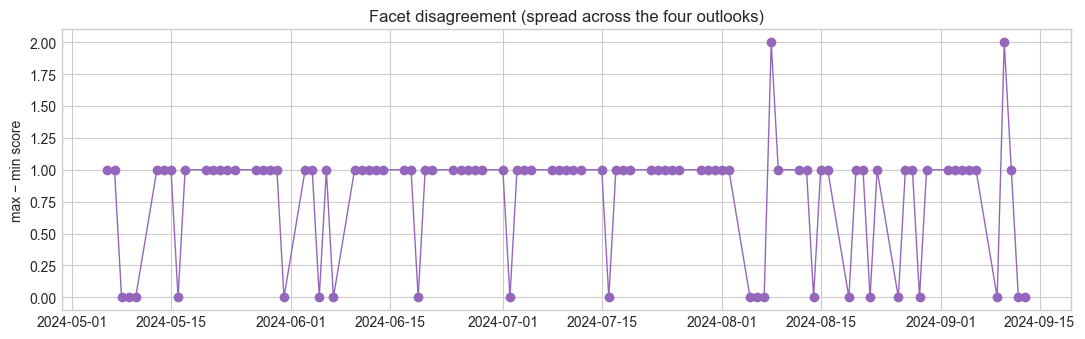

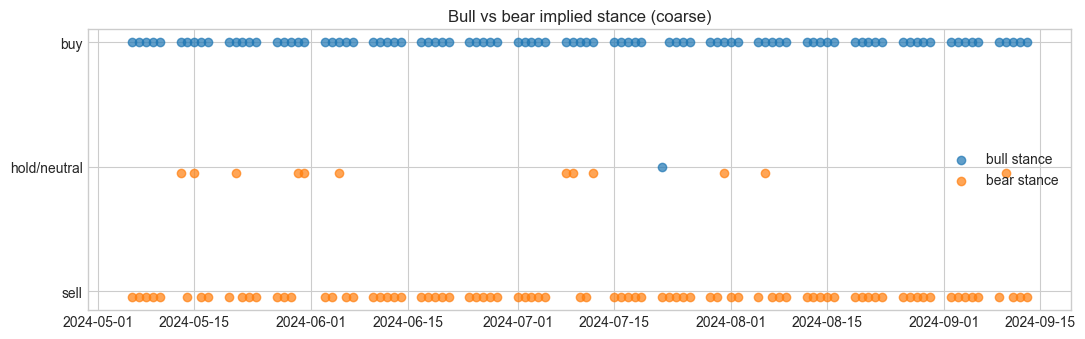

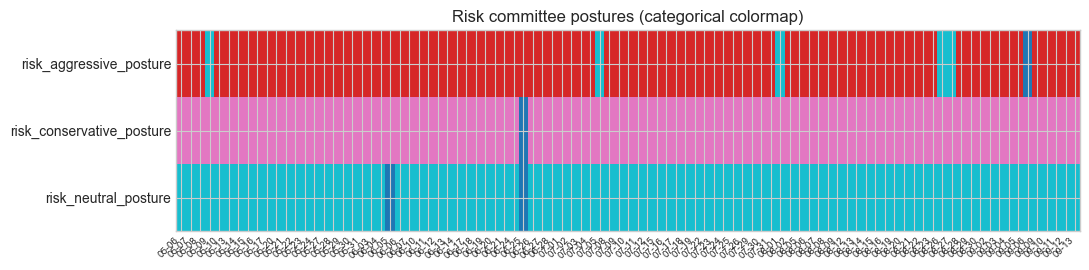

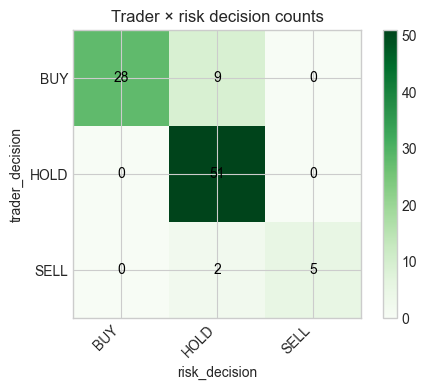

In [12]:
if all(c in dtd.columns for c in OUTLOOK_COLS):
    # Heatmap: encode outlooks as numeric for colormap
    enc = {"bullish": 1, "bearish": -1, "mixed": 0, "neutral": 0, "fallback": -2}
    mat = dtd[OUTLOOK_COLS].apply(lambda col: col.map(enc))
    dates = dtd["date"]

    fig, ax = plt.subplots(figsize=(11, max(2.5, 0.25 * len(dtd))))
    im = ax.imshow(mat.T.values, aspect="auto", cmap="RdYlGn", vmin=-2, vmax=1)
    ax.set_yticks(range(len(OUTLOOK_COLS)))
    ax.set_yticklabels(OUTLOOK_COLS)
    ax.set_xticks(range(len(dates)))
    ax.set_xticklabels([d.strftime("%m-%d") for d in dates], rotation=45, ha="right", fontsize=7)
    ax.set_title("3. Agent facets — outlook heatmap (green=bullish, red=bearish, dark=fallback)")
    plt.colorbar(im, ax=ax, fraction=0.02)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.plot(dates, dtd["facet_mean"], marker="o", lw=1, label="Mean outlook score")
    ax.axhline(0, color="gray", lw=0.8)
    if dtd["is_fallback_row"].any():
        ax.fill_between(
            dates,
            dtd["facet_mean"].min(skipna=True),
            dtd["facet_mean"].max(skipna=True),
            where=dtd["is_fallback_row"].values,
            alpha=0.2,
            color="red",
            label="fallback outlook row",
        )
    ax.set_ylabel("Score")
    ax.set_title("Facet consensus (mean of bullish/bearish/mixed map)")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.plot(dates, dtd["facet_spread"], marker="o", color="C4", lw=1)
    ax.set_ylabel("max − min score")
    ax.set_title("Facet disagreement (spread across the four outlooks)")
    plt.tight_layout()
    plt.show()

if "bull_implied_stance" in dtd.columns and "bear_implied_stance" in dtd.columns:
    fig, ax = plt.subplots(figsize=(11, 3.5))
    x = np.arange(len(dtd))
    w = 0.35
    def _count(series):
        return series.fillna("").astype(str).str.lower()

    bull = _count(dtd["bull_implied_stance"])
    bear = _count(dtd["bear_implied_stance"])
    ax.scatter(dtd["date"], bull.map({"buy": 1, "sell": -1, "hold": 0}).fillna(0), label="bull stance", alpha=0.7)
    ax.scatter(dtd["date"], bear.map({"buy": 1, "sell": -1, "hold": 0}).fillna(0) - 0.05, label="bear stance", alpha=0.7)
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(["sell", "hold/neutral", "buy"])
    ax.set_title("Bull vs bear implied stance (coarse)")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Risk postures — show as stacked category counts per day (simplified: text heatmap)
risk_cols = [
    "risk_aggressive_posture",
    "risk_conservative_posture",
    "risk_neutral_posture",
]
if all(c in dtd.columns for c in risk_cols):
    fig, ax = plt.subplots(figsize=(11, 2.8))
    R = dtd[risk_cols].fillna("").astype(str).apply(lambda c: c.str.lower())
    codes = pd.Categorical(R.values.ravel()).codes.reshape(R.shape)
    im = ax.imshow(codes.T, aspect="auto", cmap="tab10")
    ax.set_yticks(range(len(risk_cols)))
    ax.set_yticklabels(risk_cols)
    ax.set_xticks(range(len(dtd)))
    ax.set_xticklabels([d.strftime("%m-%d") for d in dtd["date"]], rotation=45, ha="right", fontsize=7)
    ax.set_title("Risk committee postures (categorical colormap)")
    plt.tight_layout()
    plt.show()

# Decision crosstab: trader vs risk
if "trader_decision" in dtd.columns and "risk_decision" in dtd.columns:
    ct = pd.crosstab(dtd["trader_decision"], dtd["risk_decision"], dropna=False)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(ct.values, cmap="Greens")
    ax.set_xticks(range(len(ct.columns)))
    ax.set_xticklabels(ct.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(ct.index)))
    ax.set_yticklabels(ct.index)
    ax.set_xlabel("risk_decision")
    ax.set_ylabel("trader_decision")
    ax.set_title("Trader × risk decision counts")
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            ax.text(j, i, int(ct.values[i, j]), ha="center", va="center", color="black")
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()


## 4. Fallback / agreement / calendar

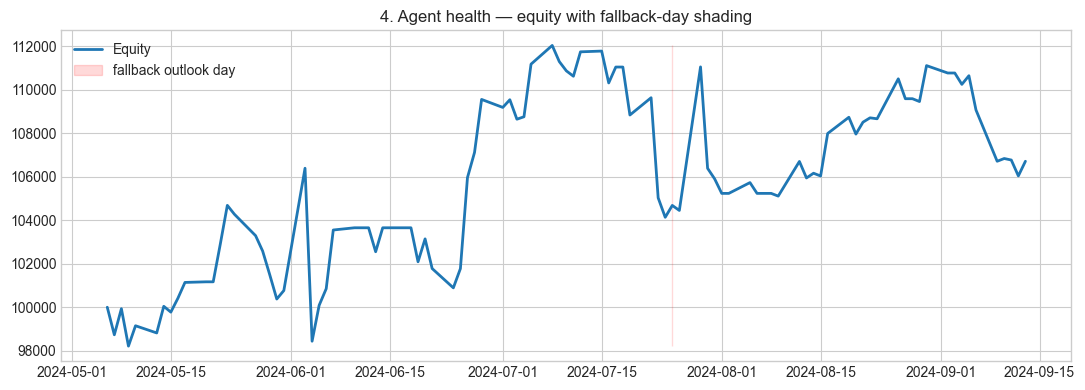

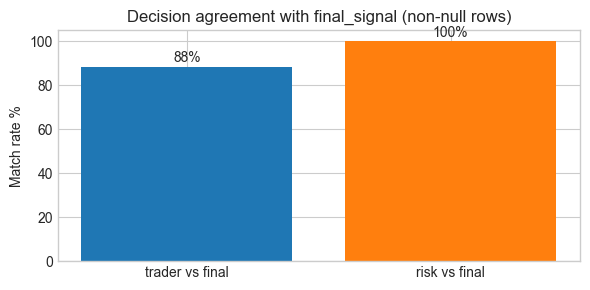

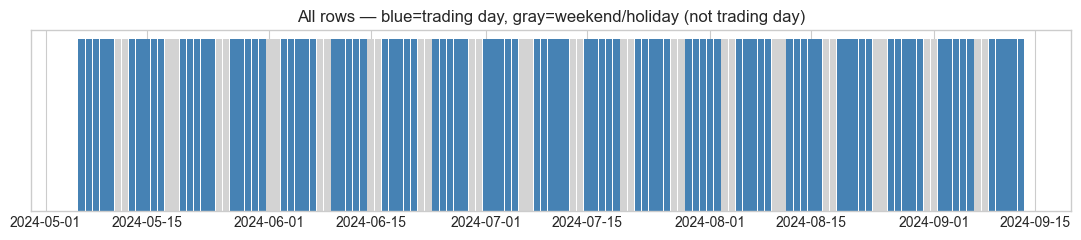

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(dtd["date"], dtd["equity"], color="C0", lw=2, label="Equity")
if dtd["is_fallback_row"].any():
    y0, y1 = dtd["equity"].min(), dtd["equity"].max()
    ax.fill_between(
        dtd["date"],
        y0,
        y1,
        where=dtd["is_fallback_row"].values,
        color="red",
        alpha=0.15,
        label="fallback outlook day",
    )
ax.set_title("4. Agent health — equity with fallback-day shading")
ax.legend()
plt.tight_layout()
plt.show()

if "trader_matches_final" in dtd.columns:
    tm = dtd["trader_matches_final"].dropna()
    rm = dtd["risk_matches_final"].dropna() if "risk_matches_final" in dtd.columns else pd.Series(dtype=float)
    fig, ax = plt.subplots(figsize=(6, 3))
    vals = [tm.mean(), rm.mean() if len(rm) else np.nan]
    labs = ["trader vs final", "risk vs final"]
    ax.bar(labs, [v * 100 if pd.notna(v) else 0 for v in vals], color=["C0", "C1"])
    ax.set_ylabel("Match rate %")
    ax.set_ylim(0, 105)
    ax.set_title("Decision agreement with final_signal (non-null rows)")
    for i, v in enumerate(vals):
        if pd.notna(v):
            ax.text(i, v * 100 + 2, f"{v*100:.0f}%", ha="center")
    plt.tight_layout()
    plt.show()

# Pipeline / calendar hygiene
fig, ax = plt.subplots(figsize=(11, 2.5))
e2 = df_all["error"].fillna("").astype(str).str.strip().str.lower()
colors_bar = np.where(e2.eq("not trading day"), "lightgray", "steelblue")
ax.bar(df_all["date"], np.ones(len(df_all)), width=0.9, color=colors_bar, align="center")
ax.set_yticks([])
ax.set_title("All rows — blue=trading day, gray=weekend/holiday (not trading day)")
plt.tight_layout()
plt.show()


## 5. Costs + rolling volatility

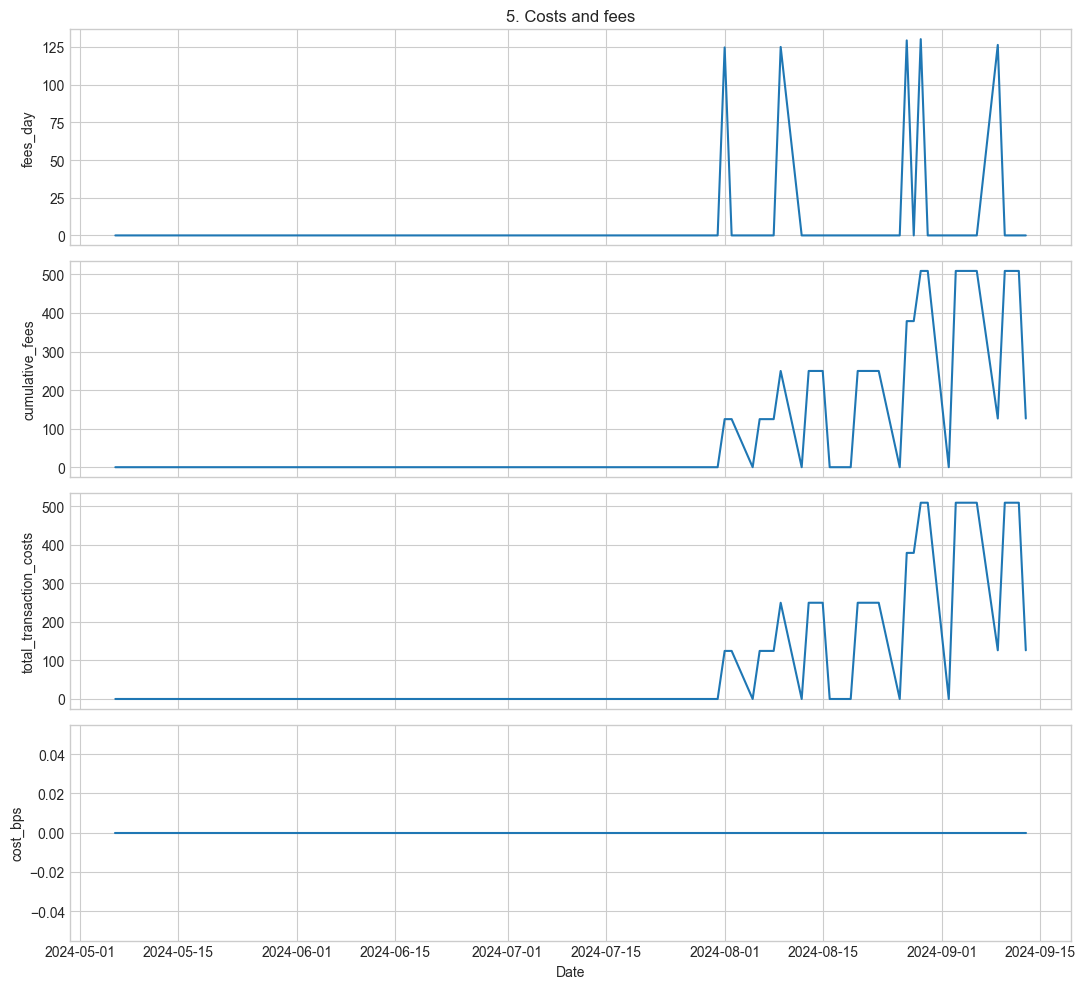

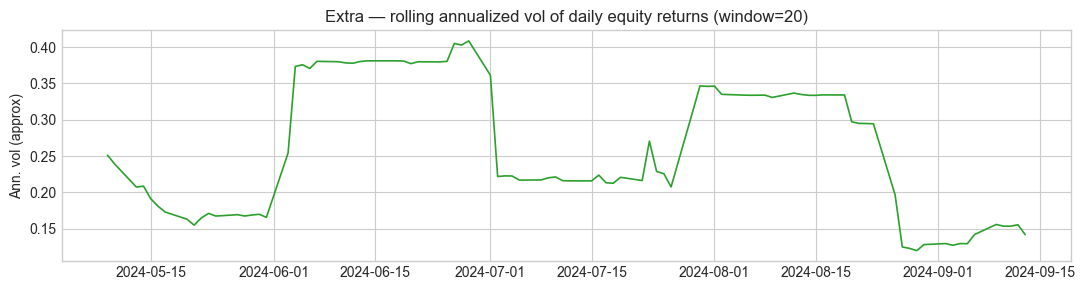

In [14]:
fee_cols = [c for c in ("fees_day", "cumulative_fees", "total_transaction_costs", "cost_bps") if c in dtd.columns]
if fee_cols:
    fig, axes = plt.subplots(len(fee_cols), 1, figsize=(11, 2.5 * len(fee_cols)), sharex=True)
    if len(fee_cols) == 1:
        axes = [axes]
    for ax, c in zip(axes, fee_cols):
        ax.plot(dtd["date"], dtd[c], lw=1.5)
        ax.set_ylabel(c)
    axes[0].set_title("5. Costs and fees")
    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()

# Rolling vol of strategy (20d window, min_periods=3)
win = min(20, max(3, len(dtd) // 3))
if len(dtd) >= 3:
    vol = dtd["strat_daily_ret"].rolling(win, min_periods=3).std() * np.sqrt(252)
    fig, ax = plt.subplots(figsize=(11, 3))
    ax.plot(dtd["date"], vol, color="C2", lw=1.2)
    ax.set_title(f"Extra — rolling annualized vol of daily equity returns (window={win})")
    ax.set_ylabel("Ann. vol (approx)")
    plt.tight_layout()
    plt.show()
